# Get data from EOCAT provider

`eocat` provides access to ESA **Third Party** and **Heritage** Missions data.

STAC API available on https://eocat.esa.int/eo-catalogue.

### Third Party Missions:
- ALOS-1, JERS-1, KOMPSAT-2, SPOT, ...

### Heritage Missions:
- ERS, ENVISAT, GOCE, ...

`eocat` uses a new authentication plugin [EOIAMAuth](../../plugins_reference/generated/eodag.plugins.authentication.eoiam.EOIAMAuth.rst) for EOIAM authentication through its HTML forms mechanism.

Registration guide on EODAG documentation: [EOCAT registration](../../providers.rst#eocat).

Set credentials in the user configuration file `~/.config/eodag/eodag.yml`:
```yaml
eocat:
    auth:
        credentials:
            username: PLEASE_CHANGE_ME
            password: PLEASE_CHANGE_ME
```
or through environment variables:
```py
os.environ["EODAG__EOCAT__AUTH__CREDENTIALS__USERNAME"] = "PLEASE_CHANGE_ME"
os.environ["EODAG__EOCAT__AUTH__CREDENTIALS__PASSWORD"] = "PLEASE_CHANGE_ME"
```

In [1]:
# Switch to minimal mode for the exception handlers
%xmode Minimal

# Filter out EOCAT search SSL certificate warning
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

from eodag import EODataAccessGateway, EOProduct, SearchResult
dag = EODataAccessGateway()

Exception reporting mode: Minimal


Check available collections

In [2]:
collections = dag.list_collections(provider="eocat")
collections

id:,"'ALOS',"
title:,"'Alos African Coverage ESA archive',"
description:,"'ALOS Africa is a dataset of the best available (cloud minimal, below 10%) African coverage acquired by AVNIR-2 in OBS mode and PRISM in OB1 mode (all Backward, Nadir and Forward views, in separated products), two different collections one for each instrument. The processing level for both AVNIR-2 and PRISM products is L1B.',"
extent:,"{ 'spatial': { 'bbox': [[-26 , -37 , 53 , 37 ] ] } , 'temporal': { 'interval': [[2006-07-09 00:00:00+00:00 , 2009-05-12 23:59:59.999000+00:00 ] ] } },"
keywords:,"['35-km-prism' , '691.65-km' , '70-km-avnir-2' , 'agriculture' , 'alos' , 'alos-1' , 'av2-obs-11' , 'avnir-2' , 'earth-science->-agriculture' , 'earth-science->-biosphere->-ecosystems->-terrestrial-ecosystems->-forests' , 'earth-science->-cryosphere->-snow/ice' , 'earth-science->-human-dimensions->-natural-hazards' , 'earth-science->-land-surface' , 'earth-science->-terrestrial-hydrosphere->-snow/ice' , 'forestry' , 'high-resolution---hr-(5---20)-m' , 'imaging-spectrometers/radiometers' , 'land-surface' , 'medium-resolution---mr-(20---500)-m' , 'natural-hazards-and-disaster-risk' , 'nir-(0.75---1.30)-µm' , 'prism' , 'psm-ob1-11' , 'snow-and-ice' , 'sun-synchronous' , 'vis-(0.40---0.75)-µm' ],"
license:,"'other',"
instruments:,"['AVNIR-2' ],"
platform:,"'ALOS-1',"
id:,"'ALOS.AVNIR-2.L1C',"
title:,"'ALOS AVNIR-2 L1C',"
description:,"'This collection is providing access to the ALOS-1 AVNIR-2 (Advanced Visible and Near Infrared Radiometer type 2) L1C data acquired by ESA stations in the ADEN zone plus some worldwide data requested by European scientists. The ADEN zone (https://earth.esa.int/eogateway/documents/20142/37627/ALOS-ADEN-Zone.pdf) was the area belonging to the European Data node and covered both the European and the African continents, large part of the Greenland and the Middle East. The full mission is covered, obviously with gaps outside to the ADEN zone: • Time windows: from 2006-04-28 to 2011-04-20 • Orbits: from 1375 to 27898 • Path (corresponds to JAXA track number): from 1 to 670 • Row (corresponds to JAXA scene centre frame number): from 370 to 5230 One single Level 1C product types is offered for the OBS instrument mode: AV2_OBS_1C. The Level 1C product is a multispectral image (three bands in VIS and one in NIR) in GEOTIFF format with 10 m resolution.',"


Search and try to download *Skysat ESA archive* data (`SkySatESAarchive` collection). 

Using our account, additional consent was not applied for this collection, which will result, whren trying to download, to an `AuthenticationError` with a link to apply for the required consent.

In [3]:
results_skysat = dag.search(collection="SkySatESAarchive", limit=5)
results_skysat

SearchResult([EOProduct(id=SSC_OPER_SSC_DEF_SC_20211015T095613_N47-862_E008-639_01, provider=eocat),
              EOProduct(id=SSC_OPER_SSC_DEF_SC_20211009T085605_N47-917_E008-831_01, provider=eocat),
              EOProduct(id=SSC_OPER_SSC_DEF_SC_20211010T083029_N47-904_E008-794_01, provider=eocat),
              EOProduct(id=SSC_OPER_SSC_DEF_SC_20211016T100919_N47-970_E008-647_01, provider=eocat),
              EOProduct(id=SSC_OPER_SSC_DEF_SC_20211009T085605_N47-898_E008-833_01, provider=eocat)])

In [4]:
results_skysat[0].download()

0.00B [00:00, ?B/s]

AuthenticationError: Data access request required: please log in to the EOIAM portal and request access to the data through this link https://tpm-ds.eo.esa.int/oads/data/SkySat/SSC_OPER_SSC_DEF_SC_20211015T095613_N47-862_E008-639_01_v0100.SIP.ZIP

As expected, authentication failed. Click on the link provided in the error message and follow instructions to apply consent for this collection.

Now search and download *SMOS-CryoSat L4 Sea Ice Thickness* (`L4_SIT_Open` collection) data, which is a collection for which access has already been granted on our account.

In [5]:
results = dag.search(
    collection="L4_SIT_Open",
    start="2011-01-01", end="2011-05-31",
    limit=5
)
results

SearchResult([EOProduct(id=W_XX-ESA,SMOS_CS2,NH_25KM_EASE2_20101226_20110101_r_v206_01_l4sit.nc, provider=eocat),
              EOProduct(id=W_XX-ESA,SMOS_CS2,NH_25KM_EASE2_20110113_20110119_r_v206_01_l4sit.nc, provider=eocat),
              EOProduct(id=W_XX-ESA,SMOS_CS2,NH_25KM_EASE2_20110103_20110109_r_v206_01_l4sit.nc, provider=eocat),
              EOProduct(id=W_XX-ESA,SMOS_CS2,NH_25KM_EASE2_20110121_20110127_r_v206_01_l4sit.nc, provider=eocat),
              EOProduct(id=W_XX-ESA,SMOS_CS2,NH_25KM_EASE2_20110107_20110113_r_v206_01_l4sit.nc, provider=eocat)])

In [6]:
path = results[0].download()
path

0.00B [00:00, ?B/s]

'/tmp/W_XX-ESA_SMOS_CS2_NH_25KM_EASE2_20101226_20110101_r_v206_01_l4sit'

Read data as Xarray using eodag-cube [to_xarray()](../../api_reference/eoproduct.rst#eodag_cube.api.product._product.EOProduct.to_xarray):

In [7]:
xd = results[0].to_xarray()
ds = next(iter(xd.values()))
ds

0.00B [00:00, ?B/s]

<xarray.Dataset> Size: 19MB
Dimensions:                                (time: 1, nv: 2, yc: 432, xc: 432)
Coordinates:
  * time                                   (time) datetime64[ns] 8B 2010-12-2...
  * yc                                     (yc) float32 2kB 5.388e+03 ... -5....
  * xc                                     (xc) float32 2kB -5.388e+03 ... 5....
    lon                                    (yc, xc) float32 746kB ...
    lat                                    (yc, xc) float32 746kB ...
Dimensions without coordinates: nv
Data variables: (12/14)
    Lambert_Azimuthal_Grid                 int32 4B ...
    time_bnds                              (time, nv) datetime64[ns] 16B ...
    analysis_sea_ice_thickness             (time, yc, xc) float64 1MB ...
    background_sea_ice_thickness           (time, yc, xc) float64 1MB ...
    weighted_mean_sea_ice_thickness        (time, yc, xc) float64 1MB ...
    innovation                             (time, yc, xc) float64 1MB ...
    ...                                     ...
    correlation_length_scale               (time, yc, xc) float64 1MB ...
    analysis_sea_ice_thickness_unc         (time, yc, xc) float64 1MB ...
    smos_sea_ice_thickness                 (time, yc, xc) float64 1MB ...
    smos_sea_ice_thickness_uncertainty     (time, yc, xc) float64 1MB ...
    cryosat_sea_ice_thickness              (time, yc, xc) float64 1MB ...
    cryosat_sea_ice_thickness_uncertainty  (time, yc, xc) float64 1MB ...
Attributes: (12/48)
    title:                     W_XX-ESA,SMOS_CS2,NH_25KM_EASE2_20101226_20110...
    description:               Weekly Arctic sea-ice thickness derived from C...
    summary:                   Weekly Arctic sea-ice thickness derived from C...
    keywords:                  Cryosphere > Sea Ice > Sea Ice Thickness
    product_version:           206
    processing_mode:           r
    ...                        ...
    eodag:thumbnail:           https://smos-diss.eo.esa.int/oads/meta/L4_SIT_...
    order:status:              succeeded
    product:acquisition_type:  nominal
    product:type:              MIR_SIT_M4
    proj:code:                 EPSG:4326
    time:published:            2010-12-26T00:00:00.000Z

And plot the data using `cartopy`:

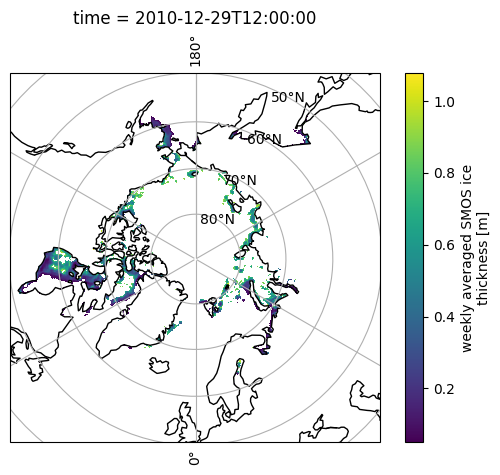

In [8]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

ax = plt.axes(projection=ccrs.NorthPolarStereo())
ds.smos_sea_ice_thickness.isel(time=0).plot.pcolormesh(
    ax=ax,
    x="lon", y="lat",
    transform=ccrs.PlateCarree(),
)
ax.coastlines()
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, x_inline=False, y_inline=True)